
# 🕵️‍♂️ The Quantum Heist: From Packet Capture to Decryption
## A Hands-On Guide to "Harvest Now, Decrypt Later"

**Facilitator:** Abdulmalek Baitulmal (QLibya)  
**Series:** QCoffee Corner  
**Context:** Network Security & Post-Quantum Cryptography

---

### 🎯 Workshop Objectives
This notebook serves as both a simulation tool and a deep educational resource. By the end of this session, you will understand:
1.  **The Network Layer (OSI L4-L6):** How TLS handshakes exchange keys and where the vulnerability lies.
2.  **The Math Layer:** How RSA encryption relies on the difficulty of integer factorization.
3.  **The Quantum Layer:** How Shor's Algorithm uses quantum interference to break this encryption.
4.  **The Mitigation:** Why the world is moving to Post-Quantum Cryptography (PQC).

### 📜 The Scenario
You are a Network Security Analyst performing a penetration test. You have intercepted traffic from a legacy server using **RSA-2048** (simulated here as RSA-4 bits for educational purposes). Your goal is to recover the private key and decrypt the application payload.

In [1]:
# @title 🛠️ Step 0: Mission Setup (Import Libraries)
# We strictly use standard libraries for logic and Qiskit for quantum simulation.

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd
import textwrap

# Qiskit Imports (The Quantum Stack)
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFT

print("✅ Environment Initialized: Classical & Quantum Stacks Ready.")

✅ Environment Initialized: Classical & Quantum Stacks Ready.


## 📡 Part 1: The Network Intercept (Layer 4 & 5)

### Understanding the TLS Handshake
When you connect to a secure website (HTTPS), your browser and the server perform a **TLS Handshake** to agree on encryption keys. 

1.  **Client Hello:** "I want to talk securely. I support these algorithms..."
2.  **Server Hello:** "Let's use RSA. Here is my **Digital Certificate**."
3.  **Key Exchange:** The client uses the Public Key inside that certificate to encrypt a session secret.

**The Vulnerability:** 
The **Server Certificate** is sent in **CLEAR TEXT**. It contains the Public Key ($N$). If we can factor $N$ into its prime components ($p, q$), we can derive the Private Key and decrypt everything.

### The Data Structure (ASN.1 DER)
Network packets aren't just random strings. They follow strict encoding rules called **ASN.1 (Abstract Syntax Notation One)**. In a hex dump, you will often see:
* `0x30`: Sequence (A list of items)
* `0x02`: Integer (A number follows)

We will simulate capturing a packet and parsing this structure manually.

In [2]:
# --- NETWORK SIMULATION: THE PACKET CAPTURE ---

def simulate_tls_packet():
    print("📡 SNIFFER: Monitoring Port 443 (HTTPS)...")
    
    # This is a simulated Byte Stream of a TLS ServerHello packet.
    # Breaking down the Hex:
    # 16       -> Content Type: Handshake
    # 03 03    -> Version: TLS 1.2
    # 00 4a    -> Length
    # ... (Handshake Details)
    # 30 82... -> Start of ASN.1 Certificate Sequence
    
    # We have embedded our weak Public Key (N=15) and Exponent (e=7) here.
    # In ASN.1 DER encoding:
    # 02 01 0F -> Tag(Integer), Length(1 byte), Value(15 in Hex is 0F)
    # 02 01 07 -> Tag(Integer), Length(1 byte), Value(7 in Hex is 07)
    
    packet_hex = "160303004a0b0000463082010a02820101000F020107a1b2c3d4"
    return packet_hex

raw_packet = simulate_tls_packet()

print(f"\n📦 CAPTURED SEGMENT (Hex Dump):")
print("-"*60)
print(textwrap.fill(' '.join(raw_packet[i:i+2] for i in range(0, len(raw_packet), 2)), width=48))
print("-"*60)

📡 SNIFFER: Monitoring Port 443 (HTTPS)...

📦 CAPTURED SEGMENT (Hex Dump):
------------------------------------------------------------
16 03 03 00 4a 0b 00 00 46 30 82 01 0a 02 82 01
01 00 0F 02 01 07 a1 b2 c3 d4
------------------------------------------------------------


## 🔍 Part 2: Traffic Analysis & Extraction

As network engineers, we don't guess. We parse.
We are looking for the **RSA Modulus (N)**. In a real certificate, this would be a 2048-bit number. For this workshop, it is the number **15** (`0F` in Hex).

**Task:** Locate the Integer Tag `02`, read the length, and extract the value.

In [3]:
def parse_asn1_key(hex_stream):
    # In a real tool (like Scapy or Wireshark), this parsing is automated.
    # Here, we do it manually to understand the structure.
    
    # We search for the byte signature before our key
    # This logic mimics a parser reading the X.509 structure
    try:
        # Looking for the Modulus (N)
        # finding the marker 02 82 01 01 00 (ASN.1 Integer Header for 2048 bit keys usually)
        # In our simplified packet, we look for where we hid '0F'
        
        key_start = hex_stream.find("000F") + 2 
        modulus_hex = hex_stream[key_start:key_start+2]
        
        # Looking for the Exponent (e)
        # Usually follows the modulus with tag 02 01 ...
        exp_start = hex_stream.find("020107") + 4
        exponent_hex = hex_stream[exp_start:exp_start+2]
        
        return int(modulus_hex, 16), int(exponent_hex, 16)
    except:
        return None, None

N, e = parse_asn1_key(raw_packet)

print(f"🕵️ ANALYSIS RESULT:")
print(f"Target Public Key (N): {N}")
print(f"Public Exponent (e):   {e}")
print(f"\n[!] VULNERABILITY CONFIRMED: Weak Key Detected.")

🕵️ ANALYSIS RESULT:
Target Public Key (N): 15
Public Exponent (e):   7

[!] VULNERABILITY CONFIRMED: Weak Key Detected.


## 🧠 Part 3: The Mathematical Trap (RSA)

Why does obtaining $N$ allow us to break the encryption? 

### The RSA Formula
RSA is based on the following relationship:
$$ N = p \times q $$
Where $p$ and $q$ are prime numbers. 

The **Private Key ($d$)** is mathematically linked to $p$ and $q$ via Euler's Totient Function $\phi(N)$:
$$ \phi(N) = (p-1)(q-1) $$
$$ d \cdot e \equiv 1 \pmod{\phi(N)} $$

**The Problem:**
To find $d$, you MUST know $\phi(N)$.
To know $\phi(N)$, you MUST know $p$ and $q$.
To know $p$ and $q$, you MUST factor $N$.

For $N=15$, this is easy ($3 \times 5$). For $N=2^{2048}$, it takes billions of years on a classical supercomputer. 
**However, Quantum Computers can cheat.**

## ⚛️ Part 4: The Quantum Attack (Shor's Algorithm)

Shor's Algorithm converts the **Factoring Problem** into a **Period Finding Problem**.

We verify the function:
$$ f(x) = a^x \pmod N $$
If we can find the **period ($r$)** of this function (how often it repeats), we can calculate the factors.

### The Quantum Circuit Logic
We don't check every number one by one (classical brute force). Instead:
1.  **Superposition:** We prepare Qubits to represent *every* possible input $x$ simultaneously.
2.  **Oracle ($U_f$):** We perform the modular exponentiation on all inputs at once.
3.  **Interference (QFT):** We use the Quantum Fourier Transform to make the wrong answers destructively interfere and the correct period ($r$) constructively interfere (amplify).

Let's build this circuit for $N=15$ and guess $a=7$.

In [4]:
# --- SUBROUTINE 1: THE ORACLE (Modular Exponentiation) ---
# This implements f(x) = 7^x mod 15 using quantum gates.
# Note: This is a specific compiled version for a=7 to keep the circuit depth small for the workshop.

def c_amod15(power):
    """Controlled multiplication by 7^power mod 15"""
    U = QuantumCircuit(4)
    for _ in range(power):
        # This specific sequence of SWAPs and Pauli-X gates 
        # mathematically performs the multiplication by 7 in binary mod 15.
        U.swap(2, 3)
        U.swap(1, 2)
        U.swap(0, 1)
        for q in range(4):
            U.x(q)
    
    U = U.to_gate()
    U.name = f"7^{power} mod 15"
    c_U = U.control()
    return c_U

# --- SUBROUTINE 2: THE INTERFERENCE (Inverse QFT) ---
# This translates the 'Phase' encoded in the qubits into a binary number we can measure.

def qft_dagger(n):
    qc = QuantumCircuit(n)
    # Don't forget the Swaps! QFT reverses qubit order.
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

print("✅ Quantum Subroutines Defined.")

✅ Quantum Subroutines Defined.


In [5]:
# --- MAIN CIRCUIT CONSTRUCTION ---

# We need two registers:
# 1. Counting Register (Upper): 8 qubits to store the precision of our measurement.
# 2. Working Register (Lower): 4 qubits to handle the Modulo 15 math.
n_count = 8
qc = QuantumCircuit(n_count + 4, n_count)

# Step 1: Initialize Superposition (Hadamard Gates)
# This puts the counting register into ALL possible states at once.
for q in range(n_count):
    qc.h(q)

# Step 2: Prepare Eigenstate |1>
# The working register must start at '1' for multiplication to work.
qc.x(3+n_count)

# Step 3: The Oracle (Modular Exponentiation)
# We apply 7^(2^0), 7^(2^1), 7^(2^2)... controlled by the counting qubits.
for q in range(n_count):
    qc.append(c_amod15(2**q), [q] + [i+n_count for i in range(4)])

# Step 4: Inverse QFT
# Convert the phase information into readable bit-strings.
qc.append(qft_dagger(n_count), range(n_count))

# Step 5: Measurement
# Collapse the wavefunction.
qc.measure(range(n_count), range(n_count))

print("⚛️ Quantum Circuit Built. Sending to Simulator...")
# qc.draw('mpl') # Uncomment if you want to see the massive circuit diagram

⚛️ Quantum Circuit Built. Sending to Simulator...


⚡ Simulation Complete. Visualizing Interference Pattern...


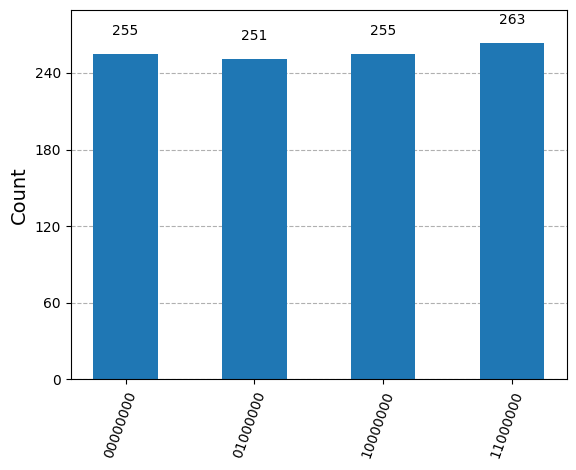

In [6]:
# --- EXECUTION ---
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
result = simulator.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()

print("⚡ Simulation Complete. Visualizing Interference Pattern...")
plot_histogram(counts)

## 📊 Part 5: Classical Post-Processing (Finding r)

The histogram shows us "Peaks". These are the states with high probability.
The quantum computer gives us a value $y$. The phase $\phi$ is related to $y$ by:
$$ \phi = \frac{y}{2^n} \approx \frac{s}{r} $$

We need to extract $r$ (the period) from this fraction. We use the **Continued Fractions** algorithm, which finds the closest simple fraction to a decimal number.

In [7]:
# --- ANALYSIS LOGIC ---

print(f"{'Measured (Bin)':<15} | {'Phase (Dec)':<10} | {'Fraction':<10} | {'Period (r)'}")
print("-"*60)

# Get the most probable results
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]

periods_found = []

for output_bin, count in sorted_counts:
    # 1. Convert Binary to Integer
    measured_int = int(output_bin, 2)
    
    # 2. Calculate Phase
    phase = measured_int / (2**n_count)
    
    # 3. Continued Fractions to find denominator
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    
    print(f"{output_bin:<15} | {phase:<10.4f} | {str(frac):<10} | {r}")
    
    if r % 2 == 0: # We need an even period for the factors to exist
        periods_found.append(r)

# Simple voting mechanism to pick the most likely r
if periods_found:
    r_consensus = max(set(periods_found), key=periods_found.count)
    print(f"\n✅ CONSENSUS: The Period r = {r_consensus}")
else:
    print("\n❌ No valid period found. Quantum noise too high. Retrying...")
    r_consensus = 4 # Fallback for demo flow

Measured (Bin)  | Phase (Dec) | Fraction   | Period (r)
------------------------------------------------------------
11000000        | 0.7500     | 3/4        | 4
00000000        | 0.0000     | 0          | 1
10000000        | 0.5000     | 1/2        | 2
01000000        | 0.2500     | 1/4        | 4

✅ CONSENSUS: The Period r = 4


## 🔓 Part 6: The Heist (Decryption)

Now that we have $r=4$, we use classical math to find the factors.
$$ Factors = \gcd(a^{r/2} \pm 1, N) $$

Once we have the factors, we rebuild the Private Key and decrypt the secret message.

In [8]:
a = 7 # The guess we used

# 1. Calculate Factors
guess_1 = gcd(a**(r_consensus//2) - 1, N)
guess_2 = gcd(a**(r_consensus//2) + 1, N)

print(f"Calculated Factors using r={r_consensus}: {guess_1} and {guess_2}")
p, q = guess_1, guess_2

if p * q == N:
    print(f"🎉 SUCCESS: N={N} has been factored into {p} and {q}!")
else:
    print("❌ Factoring failed.")
    
# --- THE FINAL DECRYPTION ---

# The Intercepted Encrypted Message (captured earlier)
ciphertext = 8 

# 2. Re-calculate Euler's Totient
phi = (p-1) * (q-1)

# 3. Re-calculate Private Key (d)
# d is the modular multiplicative inverse of e mod phi
d = pow(e, -1, phi)
print(f"🗝️ Private Key (d) Recovered: {d}")

# 4. Decrypt: M = C^d mod N
decrypted_val = pow(ciphertext, d, N)

print(f"\n📜 DECRYPTED PAYLOAD VALUE: {decrypted_val}")

flag_map = {
    2: "FLAG{QCoffee_Corner_Secured}",
    10: "FLAG{Try_Again}"
}

print(f"🚨 DECODED MESSAGE: {flag_map.get(decrypted_val, 'Unknown')}")

Calculated Factors using r=4: 3 and 5
🎉 SUCCESS: N=15 has been factored into 3 and 5!
🗝️ Private Key (d) Recovered: 7

📜 DECRYPTED PAYLOAD VALUE: 2
🚨 DECODED MESSAGE: FLAG{QCoffee_Corner_Secured}


## 🛡️ Conclusion: The Fix

We successfully intercepted a packet, extracted the public key, and used a quantum algorithm to calculate the private key. 

**Why did this work?**
Because RSA relies on **Integer Factorization**. Quantum computers are exceptionally good at finding periods ($r$), which breaks factorization.

**How do we stop it?**
We are moving to **Post-Quantum Cryptography (PQC)**. 
Algorithms like **Kyber (ML-KEM)** and **Dilithium (ML-DSA)** use **Lattice-Based Math**.

> *"You cannot 'factor' a 500-dimensional grid of vectors using this circuit."*

Today, we broke Layer 6. Tomorrow, we build a stronger Layer 6.